# Full Pipeline Test - Stage 3 Extraction

Test từng bước của pipeline với synthetic chart có ground truth.

**Steps:**
1. Setup & Check GPU
2. Create synthetic chart (ground truth)
3. Preprocessing
4. OCR Extraction
5. Element Detection
6. Axis Calibration
7. Final Output & Evaluation

## Step 0: Setup & GPU Check

In [ ]:
# Restart kernel before running this cell if you encounter DLL errors
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from PIL import Image
import io
import json

print('=== ENVIRONMENT CHECK ===')

# Check PaddlePaddle GPU
print('\n[PaddlePaddle]')
try:
    import paddle
    print(f'  Version: {paddle.__version__}')
    print(f'  CUDA compiled: {paddle.device.is_compiled_with_cuda()}')
except Exception as e:
    print(f'  Error: {e}')

# Check PyTorch GPU (for ResNet classifier)
print('\n[PyTorch]')
try:
    import torch
    print(f'  Version: {torch.__version__}')
    print(f'  CUDA available: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'  CUDA device: {torch.cuda.get_device_name(0)}')
except Exception as e:
    print(f'  Error loading PyTorch: {e}')
    print('  NOTE: If DLL error, restart kernel and try again')

print('\n[OpenCV]')
print(f'  Version: {cv2.__version__}')

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.8/bin'

## Step 1: Create Synthetic Chart (Ground Truth)

In [2]:
# === GROUND TRUTH DATA ===
GROUND_TRUTH = {
    'chart_type': 'bar',
    'title': 'Monthly Sales 2025',
    'x_label': 'Month',
    'y_label': 'Revenue (USD)',
    'x_values': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'y_values': [1200, 1800, 1500, 2200, 1900],
    'bar_color': '#4472C4',
}

print('=== GROUND TRUTH ===')
for k, v in GROUND_TRUTH.items():
    print(f'  {k}: {v}')

=== GROUND TRUTH ===
  chart_type: bar
  title: Monthly Sales 2025
  x_label: Month
  y_label: Revenue (USD)
  x_values: ['Jan', 'Feb', 'Mar', 'Apr', 'May']
  y_values: [1200, 1800, 1500, 2200, 1900]
  bar_color: #4472C4


Image shape: (552, 863, 3) (H x W x C)
Image dtype: uint8
Saved to: ..\data\samples\test_bar_chart.png


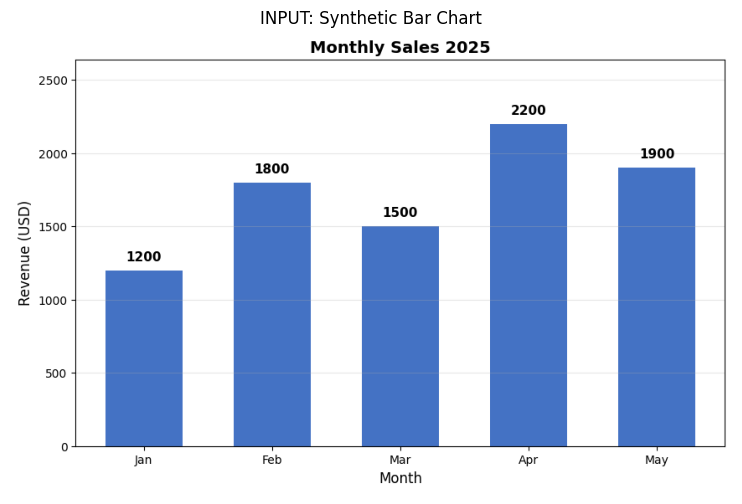

In [3]:
def create_bar_chart(data: dict) -> np.ndarray:
    """Create bar chart and return as BGR numpy array."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    x = np.arange(len(data['x_values']))
    bars = ax.bar(x, data['y_values'], color=data['bar_color'], width=0.6)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, data['y_values']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel(data['x_label'], fontsize=12)
    ax.set_ylabel(data['y_label'], fontsize=12)
    ax.set_title(data['title'], fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(data['x_values'])
    ax.set_ylim(0, max(data['y_values']) * 1.2)
    
    # Add grid
    ax.yaxis.grid(True, alpha=0.3)
    
    # Convert to numpy
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor='white', edgecolor='none')
    buf.seek(0)
    img = Image.open(buf)
    img_array = np.array(img)
    plt.close(fig)
    
    # Convert RGBA to BGR
    if img_array.shape[-1] == 4:
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGBA2BGR)
    else:
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    
    return img_bgr

# Create chart
test_image = create_bar_chart(GROUND_TRUTH)
print(f'Image shape: {test_image.shape} (H x W x C)')
print(f'Image dtype: {test_image.dtype}')

# Save for reference
save_path = Path('../data/samples/test_bar_chart.png')
save_path.parent.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(save_path), test_image)
print(f'Saved to: {save_path}')

# Display
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.title('INPUT: Synthetic Bar Chart')
plt.axis('off')
plt.show()

## Step 2: Preprocessing

In [5]:
# Direct import to avoid PyTorch DLL issue
import sys
sys.path.insert(0, '../src')

from core_engine.stages.s3_extraction.preprocessor import ImagePreprocessor as Preprocessor, PreprocessConfig

# Initialize preprocessor
preprocess_config = PreprocessConfig()
preprocessor = Preprocessor(preprocess_config)

print('=== PREPROCESSING ===')
preprocess_result = preprocessor.process(test_image, chart_id='test_001')

print(f'Original size: {test_image.shape[:2]}')
print(f'Binary shape: {preprocess_result.binary.shape}')
print(f'Cleaned shape: {preprocess_result.cleaned.shape}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(preprocess_result.binary, cmap='gray')
axes[1].set_title('Binary')
axes[1].axis('off')

axes[2].imshow(preprocess_result.cleaned, cmap='gray')
axes[2].set_title('Cleaned')
axes[2].axis('off')

plt.tight_layout()
plt.show()

OSError: [WinError 127] The specified procedure could not be found. Error loading "d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

## Step 3: OCR Extraction

In [ ]:
from core_engine.stages.s3_extraction.ocr_engine import OCREngine, OCRConfig

# Initialize OCR
ocr_config = OCRConfig(
    engine='paddleocr',
    use_gpu=False,  # Set True if paddlepaddle-gpu installed
    use_cache=False,
    classify_roles=True,
)
ocr_engine = OCREngine(ocr_config)

print('=== OCR EXTRACTION ===')
ocr_result = ocr_engine.extract_text(
    test_image,
    chart_id='test_001',
)

print(f'Texts found: {len(ocr_result.texts)}')
print(f'Mean confidence: {ocr_result.mean_confidence:.2%}')
print()

# Print detected texts
print('Detected texts:')
print(f'{"#":<3} {"Role":<12} {"Conf":>6} {"Text"}')
print('-' * 50)
for i, t in enumerate(ocr_result.texts):
    role = t.role.value if hasattr(t.role, 'value') else str(t.role) if t.role else '-'
    print(f'{i+1:<3} {role:<12} {t.confidence:>6.2%} "{t.text}"')

In [ ]:
# Visualize OCR results
def visualize_ocr(image: np.ndarray, ocr_result):
    vis = image.copy()
    
    # Color by role
    role_colors = {
        'title': (0, 0, 255),      # Red
        'x_label': (0, 255, 0),    # Green
        'y_label': (255, 0, 0),    # Blue
        'x_tick': (0, 255, 255),   # Yellow
        'y_tick': (255, 255, 0),   # Cyan
        'data_label': (255, 0, 255), # Magenta
        'legend': (128, 128, 0),   # Olive
    }
    
    for t in ocr_result.texts:
        if t.bbox:
            role = t.role.value if hasattr(t.role, 'value') else 'unknown'
            color = role_colors.get(role, (128, 128, 128))
            
            cv2.rectangle(vis,
                         (t.bbox.x_min, t.bbox.y_min),
                         (t.bbox.x_max, t.bbox.y_max),
                         color, 2)
            
            # Add label
            cv2.putText(vis, f'{role[:3]}', 
                       (t.bbox.x_min, t.bbox.y_min - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    
    return vis

ocr_vis = visualize_ocr(test_image, ocr_result)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(ocr_vis, cv2.COLOR_BGR2RGB))
plt.title('OCR Results (colored by role)')
plt.axis('off')
plt.show()

print('Legend: Red=title, Green=x_label, Blue=y_label, Yellow=x_tick, Cyan=y_tick, Magenta=data_label')

In [ ]:
# Compare with ground truth
print('=== OCR vs GROUND TRUTH ===')

detected_texts = [t.text for t in ocr_result.texts]

# Check title
title_found = any(GROUND_TRUTH['title'].lower() in t.lower() for t in detected_texts)
print(f'Title "{GROUND_TRUTH["title"]}" found: {title_found}')

# Check x labels
x_labels_found = [lbl for lbl in GROUND_TRUTH['x_values'] if any(lbl.lower() in t.lower() for t in detected_texts)]
print(f'X labels found: {x_labels_found} / {GROUND_TRUTH["x_values"]}')

# Check y values
detected_nums = []
for t in detected_texts:
    try:
        num = int(t.replace(',', '').strip())
        detected_nums.append(num)
    except:
        pass

y_values_found = [v for v in GROUND_TRUTH['y_values'] if v in detected_nums]
print(f'Y values found: {y_values_found} / {GROUND_TRUTH["y_values"]}')

## Step 4: Element Detection

In [ ]:
from core_engine.stages.s3_extraction.element_detector import ElementDetector, ElementDetectorConfig

# Initialize
elem_config = ElementDetectorConfig()
element_detector = ElementDetector(elem_config)

print('=== ELEMENT DETECTION ===')
elem_result = element_detector.detect(
    preprocess_result.binary,
    test_image,
    chart_id='test_001'
)

print(f'Bars detected: {len(elem_result.bars)}')
print(f'Markers detected: {len(elem_result.markers)}')
print(f'Slices detected: {len(elem_result.slices)}')
print()

# Expected: 5 bars
print(f'Expected bars: {len(GROUND_TRUTH["y_values"])}')
print(f'Match: {len(elem_result.bars) == len(GROUND_TRUTH["y_values"])}')

In [ ]:
# Print bar details
print('=== DETECTED BARS ===')
print(f'{"#":<3} {"Center":>15} {"Size":>12} {"Area":>8} {"Color"}')
print('-' * 60)

for i, bar in enumerate(elem_result.bars):
    center = f'({bar.center.x:4d}, {bar.center.y:4d})'
    size = f'{bar.x_max - bar.x_min:3d} x {bar.y_max - bar.y_min:3d}'
    color = f'RGB({bar.color.r}, {bar.color.g}, {bar.color.b})' if bar.color else 'N/A'
    print(f'{i+1:<3} {center:>15} {size:>12} {bar.area:>8.0f} {color}')

In [ ]:
# Visualize elements
def visualize_elements(image: np.ndarray, elem_result):
    vis = image.copy()
    
    # Draw bars (red)
    for bar in elem_result.bars:
        cv2.rectangle(vis,
                     (int(bar.x_min), int(bar.y_min)),
                     (int(bar.x_max), int(bar.y_max)),
                     (0, 0, 255), 2)
        cv2.circle(vis, (int(bar.center.x), int(bar.center.y)), 5, (0, 0, 255), -1)
    
    # Draw markers (green)
    for m in elem_result.markers:
        cv2.circle(vis, (int(m.center.x), int(m.center.y)), int(m.size), (0, 255, 0), 2)
    
    return vis

elem_vis = visualize_elements(test_image, elem_result)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(elem_vis, cv2.COLOR_BGR2RGB))
plt.title(f'Element Detection: {len(elem_result.bars)} bars, {len(elem_result.markers)} markers')
plt.axis('off')
plt.show()

## Step 5: Axis Calibration

In [ ]:
from core_engine.stages.s3_extraction.axis_calibrator import AxisCalibrator

# Initialize
calibrator = AxisCalibrator()

print('=== AXIS CALIBRATION ===')
h, w = test_image.shape[:2]
axis_info = calibrator.calibrate(ocr_result.texts, w, h)

print(f'X-axis detected: {axis_info.x_axis_detected}')
print(f'Y-axis detected: {axis_info.y_axis_detected}')
print(f'Y range: {axis_info.y_min} - {axis_info.y_max}')
print(f'Y scale factor: {axis_info.y_scale_factor} pixels/unit')
print(f'Y calibration confidence: {axis_info.y_calibration_confidence:.2%}')

In [ ]:
# Try to map bar heights to values
print('=== BAR VALUE MAPPING ===')

if axis_info.y_scale_factor and axis_info.y_scale_factor > 0:
    # Find y-axis origin (bottom of plot area)
    y_origin = None
    for t in ocr_result.texts:
        if t.role and 'y_tick' in str(t.role):
            try:
                if int(t.text) == 0:
                    y_origin = t.bbox.y_max if t.bbox else None
                    break
            except:
                pass
    
    if y_origin:
        print(f'Y-axis origin (y=0): pixel row {y_origin}')
        print()
        print(f'{"Bar":<5} {"Top Y":>8} {"Height":>8} {"Est. Value":>12} {"GT Value":>10}')
        print('-' * 50)
        
        # Sort bars by x position
        sorted_bars = sorted(elem_result.bars, key=lambda b: b.center.x)
        
        for i, bar in enumerate(sorted_bars):
            bar_top = bar.y_min
            height_px = y_origin - bar_top
            est_value = height_px / axis_info.y_scale_factor if axis_info.y_scale_factor else 0
            gt_value = GROUND_TRUTH['y_values'][i] if i < len(GROUND_TRUTH['y_values']) else '?'
            
            print(f'{i+1:<5} {bar_top:>8} {height_px:>8} {est_value:>12.0f} {gt_value:>10}')
else:
    print('Axis calibration failed - cannot map values')

## Step 6: Full Stage 3 Pipeline

In [ ]:
from core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig

# Full config
full_config = ExtractionConfig(
    ocr_engine='paddleocr',
    use_resnet_classifier=False,
    use_ml_classifier=False,
    enable_classification=False,
    enable_vectorization=False,  # Skip slow skeletonization
    enable_element_detection=True,
    enable_ocr=True,
)
full_config.ocr.use_gpu = False
full_config.ocr.use_cache = False

print('=== FULL STAGE 3 PIPELINE ===')
stage3 = Stage3Extraction(full_config)

full_result = stage3.process_image(
    test_image,
    chart_id='test_001',
)

print(f'Chart ID: {full_result.chart_id}')
print(f'Chart Type: {full_result.chart_type}')
print(f'Texts: {len(full_result.texts)}')
print(f'Elements: {len(full_result.elements)}')
print(f'Axis Info: {"Yes" if full_result.axis_info else "No"}')
print(f'Confidence: {full_result.confidence}')

## Step 7: Final Output & Evaluation

In [ ]:
# Convert to JSON-serializable format (like batch script)
output_data = {
    'chart_id': full_result.chart_id,
    'chart_type': full_result.chart_type.value if hasattr(full_result.chart_type, 'value') else str(full_result.chart_type),
    'image_size': {'width': test_image.shape[1], 'height': test_image.shape[0]},
    'texts': [
        {
            'text': t.text,
            'role': t.role.value if hasattr(t.role, 'value') else str(t.role) if t.role else None,
            'confidence': t.confidence,
            'bbox': {'x_min': t.bbox.x_min, 'y_min': t.bbox.y_min, 'x_max': t.bbox.x_max, 'y_max': t.bbox.y_max} if t.bbox else None,
        }
        for t in full_result.texts
    ],
    'elements': [
        {
            'element_type': e.element_type,
            'bbox': {'x_min': e.bbox.x_min, 'y_min': e.bbox.y_min, 'x_max': e.bbox.x_max, 'y_max': e.bbox.y_max} if e.bbox else None,
            'center': {'x': e.center.x, 'y': e.center.y} if e.center else None,
            'color': {'r': e.color.r, 'g': e.color.g, 'b': e.color.b} if e.color else None,
            'area_pixels': e.area_pixels,
        }
        for e in full_result.elements
    ],
    'axis_info': full_result.axis_info.model_dump() if full_result.axis_info else None,
}

print('=== JSON OUTPUT (preview) ===')
print(json.dumps(output_data, indent=2)[:2000])
print('...')

In [ ]:
# Final evaluation
print('=' * 60)
print('FINAL EVALUATION')
print('=' * 60)

detected_texts = [t.text for t in full_result.texts]

# 1. Title
title_ok = any(GROUND_TRUTH['title'].lower() in t.lower() for t in detected_texts)
print(f'[{"OK" if title_ok else "FAIL"}] Title detection')

# 2. X labels
x_found = sum(1 for lbl in GROUND_TRUTH['x_values'] if any(lbl.lower() in t.lower() for t in detected_texts))
x_ok = x_found == len(GROUND_TRUTH['x_values'])
print(f'[{"OK" if x_ok else "FAIL"}] X labels: {x_found}/{len(GROUND_TRUTH["x_values"])}')

# 3. Y values
detected_nums = set()
for t in detected_texts:
    try:
        detected_nums.add(int(t.replace(',', '').strip()))
    except:
        pass
y_found = sum(1 for v in GROUND_TRUTH['y_values'] if v in detected_nums)
y_ok = y_found == len(GROUND_TRUTH['y_values'])
print(f'[{"OK" if y_ok else "FAIL"}] Y values: {y_found}/{len(GROUND_TRUTH["y_values"])}')

# 4. Bar count
bar_elements = [e for e in full_result.elements if e.element_type == 'bar']
bar_ok = len(bar_elements) == len(GROUND_TRUTH['y_values'])
print(f'[{"OK" if bar_ok else "FAIL"}] Bar detection: {len(bar_elements)}/{len(GROUND_TRUTH["y_values"])}')

# Summary
total = 4
passed = sum([title_ok, x_ok, y_ok, bar_ok])
print()
print(f'SCORE: {passed}/{total} ({100*passed/total:.0f}%)')

In [ ]:
# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Original
axes[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('INPUT: Original Chart')
axes[0].axis('off')

# With detections
vis = test_image.copy()
for t in full_result.texts:
    if t.bbox:
        cv2.rectangle(vis, (t.bbox.x_min, t.bbox.y_min), (t.bbox.x_max, t.bbox.y_max), (0, 255, 0), 1)
for e in full_result.elements:
    if e.bbox and e.element_type == 'bar':
        cv2.rectangle(vis, (e.bbox.x_min, e.bbox.y_min), (e.bbox.x_max, e.bbox.y_max), (0, 0, 255), 2)

axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'OUTPUT: {len(full_result.texts)} texts, {len(bar_elements)} bars')
axes[1].axis('off')

plt.tight_layout()
plt.show()